<a href="https://colab.research.google.com/github/pacortiz9/Actividad-2.1/blob/main/ti3002c_uf4_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib
from sklearn import datasets

In [2]:
COLORS = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple',
    'tab:brown',
    'tab:pink',
    'tab:gray',
    'tab:olive',
    'tab:cyan',
]

def show_clusters_centroids(clusters,
                            centroids,
                            title,
                            x_var_indx=0,
                            y_var_indx=1,
                            x_var_name='Variable 1',
                            y_var_name="Variable 2",
                            keep=False):

    """
    Show the current clustering for 1 second and save the plot
    Input:
        clusters (list of lists of lists): A List of Clusters. Each cluster
        is also a list of points in the cluster. SEE: k_means.get_clusters()
        centroids (list of lists): A list with the current centroids
        title (string): The title for the plot.
    """

    for i, cluster in enumerate(clusters):
        cluster = np.array(cluster)
        plt.scatter(
            cluster[:,x_var_indx],
            cluster[:,y_var_indx],
            c = COLORS[i],
            label="Cluster {}".format(i)
        )

    for i, centroid in enumerate(centroids):
        plt.scatter(
            centroid[x_var_indx],
            centroid[y_var_indx],
            c = COLORS[i],
            marker='x',
            s=100
        )

    plt.title(title)
    plt.xlabel(x_var_name)
    plt.ylabel(y_var_name)
    plt.legend()

    # if not os.path.isdir('./images/kmeans_out/'):
    #     os.mkdir('./images/kmeans_out')

    # plt.savefig("./images/kmeans_out/kmeans_{}.png".format(title))

    plt.show()

In [9]:
def distance(a,b):
    """
    Compute Euclidean Distance Between Two Points
    Input:
        a (list): an n-dimensional list or array
        b (list): an n-dimensional list or array
    Output:
        The Euclidean Distance between vectors a and b
    """

    # All you need to do here is calculate the Euclidean Distance between
    # points a and b and return it

    suma_cuadrados = sum((np.array(a) - np.array(b))**2)
    euc_dist = np.sqrt(suma_cuadrados)

    return euc_dist

In [5]:
def get_clusters(points,centroids):
    """
    Returns a list of clusters given all the points in the dataset and
    the current centroids.
    Input:
        points (numpy array): a 2D (M,N) Array with the data to cluster.
        M = Instances, N = Variables.
        centroids (list of numpy arrays): A list with the k current centroids
    Output:
        clusters (list of lists of numpy arrays): A List of Clusters. Each cluster
        is also a list of numpy arrays.
    """
    clusters = [[] for f in centroids]

    for i, point in enumerate(points):
        point_to_centroids = []
        for j, centroid in enumerate(centroids):
            # Make sure you find the distance from each point to the
            # centroid and append it to point_to_centroids
            point_to_centroids.append(distance(point, centroid))
        # Now find the index of the smallest value in point_to_centroids
        # and use it to add the point to the corresponding cluster
        idx = np.argmin(point_to_centroids)
        clusters[idx].append(point)

    return clusters

In [20]:
def update_centroids(clusters):
    """
    Given a list of clusters (as prepared by get_clusters()) get the new centroids
    Input:
        clusters (list of numpy arrays): A List of Clusters. Each cluster
        is a 2D Array, rows = instances, columns=variables
    Output:
        A (list of numpy arrays): The new centroids.
    """
    new_centroids = []

    for cluster in clusters:
        # Find the average for each row in the cluster.
        # TIP: use the power of numpy!

        centroid = np.mean(cluster, axis=0)
        new_centroids.append(centroid)

    return new_centroids

In [29]:
def k_means(points, k, iterations=100):
    """
    K Means Unsupervised ML Algorithm Implementation with Forgy Initialization
    Input:
        points (numpy array): a 2D (M,N) Array with the data to cluster.
        M = Instances, N = variables.
        k (int): The number of clusters to find
    """
    idx = np.random.randint(len(points),size=k)

    centroids = points[idx,:]
    clusters = get_clusters(points,centroids)

    for i in range(iterations):

        # Use get_clusters() and update_centroids() for each iteration.
        get_clusters(points,centroids)
        centroids = update_centroids(clusters)

    return clusters,centroids

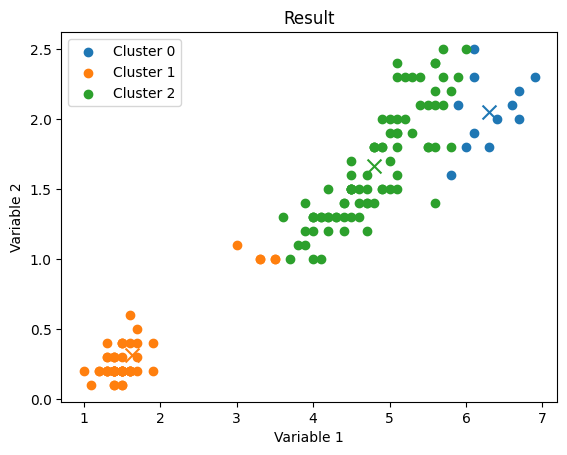

In [32]:
iris = datasets.load_iris()
k = 3

X = iris.data
y = iris.target

clusters,centroids = k_means(X,3)

show_clusters_centroids(clusters, centroids, "Result", x_var_indx=2,y_var_indx=3,keep=True)